In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [142]:
df = pd.read_csv("water_potability.csv")

In [143]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [145]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [146]:
X = df.drop(columns=['Potability']) 
y = df['Potability']

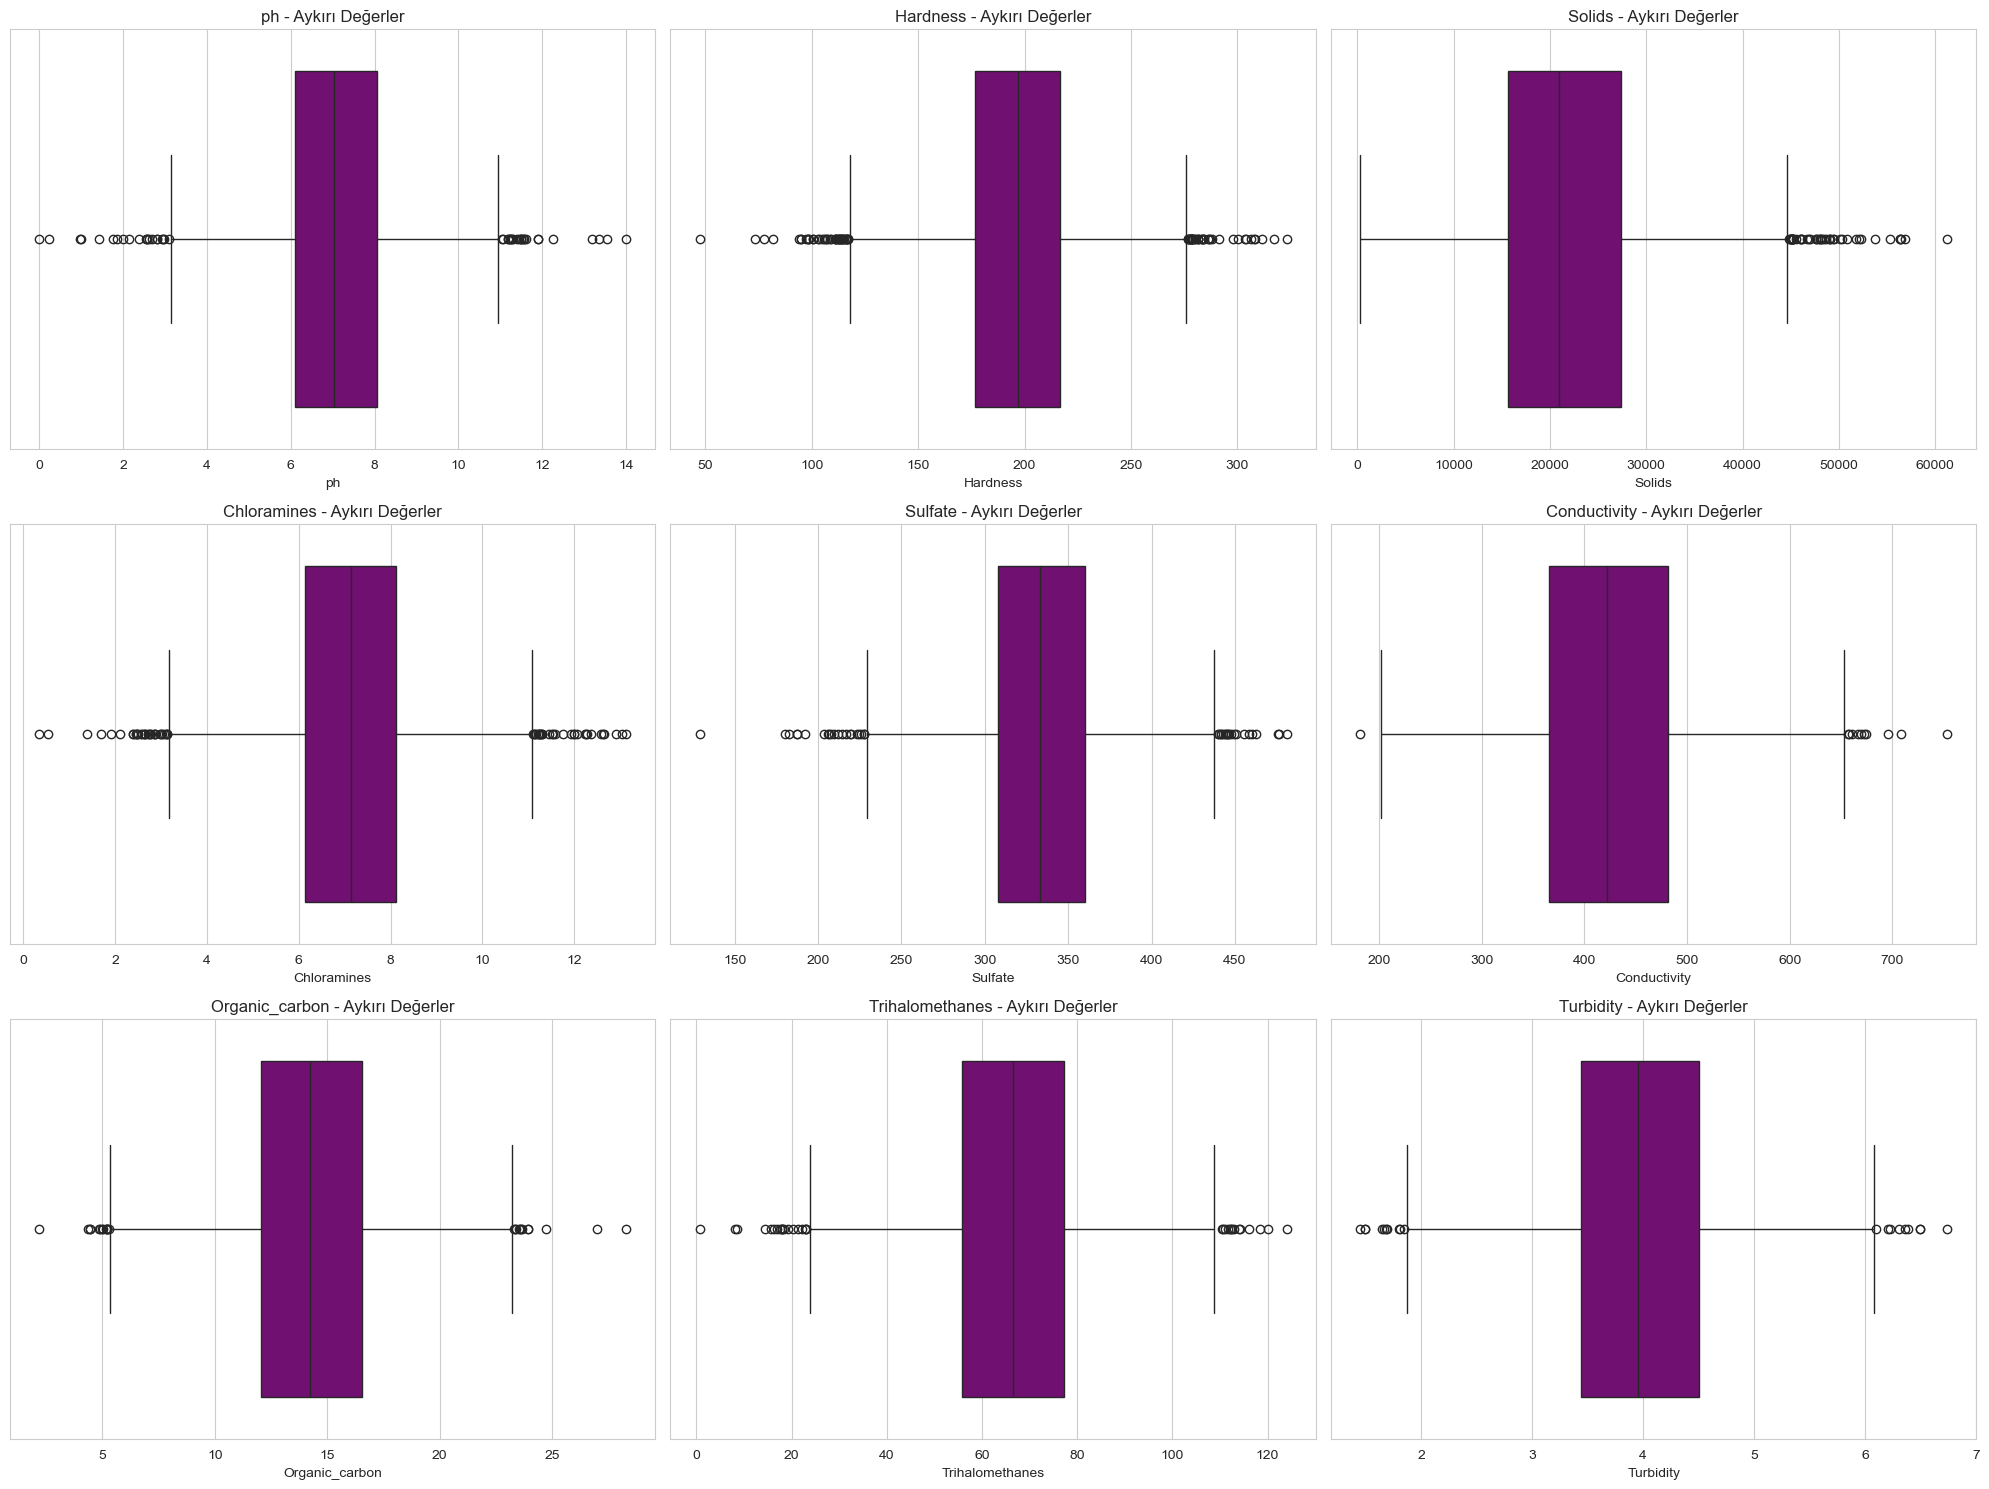

In [147]:
plt.figure(figsize=(20, 15)) 
for i, col in enumerate(X): #sütun ismi ve indexi
    plt.subplot(3, 3, i + 1) 
    sns.boxplot(x=df[col], color="purple")  
    plt.title(f"{col} - Aykırı Değerler") 
    plt.xlabel(col)
plt.tight_layout() #yazılar grafiğin üstüne gelmesin diye
plt.show()

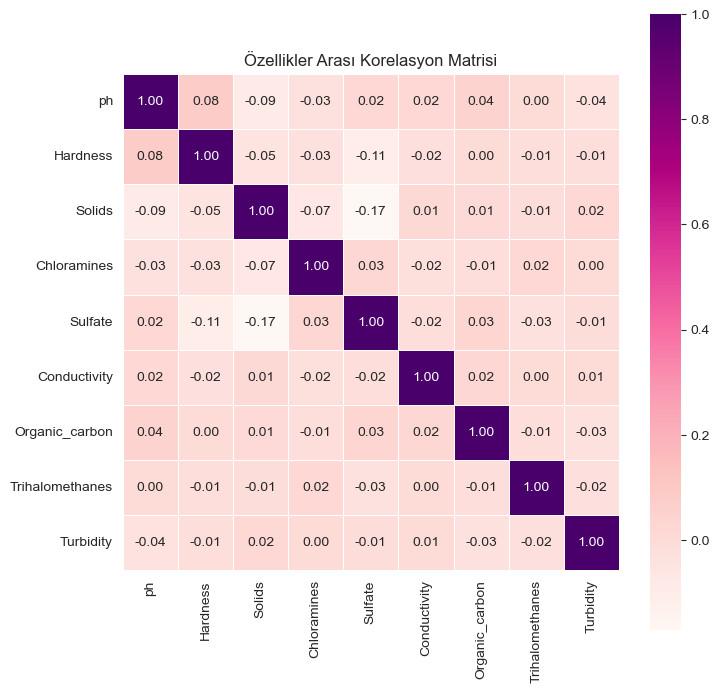

In [148]:
corr_matrix = X.corr()
plt.figure(figsize=(8, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdPu",
    square=True,
    linewidths=0.5
)
plt.title("Özellikler Arası Korelasyon Matrisi")
plt.show()


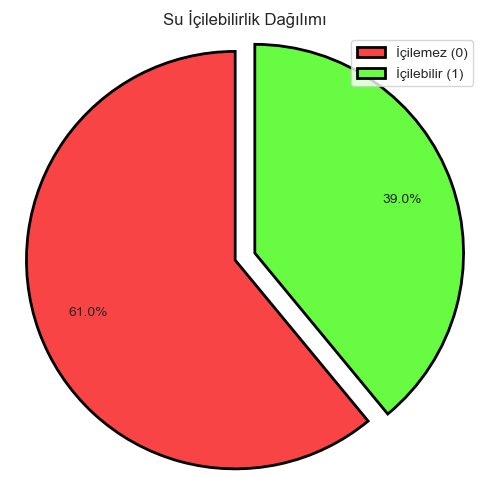

In [149]:
labels = ['İçilemez (0)', 'İçilebilir (1)']

sizes = df['Potability'].value_counts().reindex([0, 1]) #kaç 0 kaç 1 var

colors = ['#f84444', '#67fb41']
explode = (0.05, 0.05) #0 ve 1 arasındaki boşluk ayarı

plt.figure(figsize=(5, 5))
plt.pie(
    sizes,
    colors=colors,
    explode=explode,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75, #yazının merkeze yakınlığı
    wedgeprops={'edgecolor': 'black', 'linewidth': 2} #yeşil kırmızıyı ayırma
)

plt.title('Su İçilebilirlik Dağılımı')
plt.legend(labels, loc='upper right')
plt.axis('equal')
plt.tight_layout()
plt.show()


In [150]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42,  shuffle=True
)
#stratify=y: Hedef değişkenimizdeki dağılımı koru.
#random_state=42: veriyi karıştır ama her seferinde aynı şekilde karıştır
#shuffle=True: verileri karıştırır
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, shuffle=True
)
print(f"Toplam Veri Sayısı: {len(df)}")
print(f"Train Seti (%70)  : {len(X_train)}")
print(f"Val Seti   (%15)  : {len(X_val)}")
print(f"Test Seti  (%15)  : {len(X_test)}")

Toplam Veri Sayısı: 3276
Train Seti (%70)  : 2293
Val Seti   (%15)  : 491
Test Seti  (%15)  : 492


In [151]:
for col in X_train.columns:
    median_val = X_train[col].median() #sadece train'den öğren
    X_train[col].fillna(median_val, inplace=True)
    X_test[col].fillna(median_val, inplace=True)
    X_val[col].fillna(median_val, inplace=True)

C:\Users\helon\AppData\Local\Temp\ipykernel_4276\2728994757.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train[col].fillna(median_val, inplace=True)
C:\Users\helon\AppData\Local\Temp\ipykernel_4276\2728994757.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [152]:
X_train_cv, X_test_cv, y_train_cv, y_test_cv = train_test_split(
    X, y, test_size=0.15, random_state=42, shuffle=True
)

for col in X_train_cv.columns: #medyanla boş verileri doldur
    median_val = X_train_cv[col].median()
    X_train_cv[col] = X_train_cv[col].fillna(median_val)
    X_test_cv[col] = X_test_cv[col].fillna(median_val)

In [153]:
#her set için toplam boş değer sayısını yazdır
print(f"Eğitim (Train) Setindeki Boş Değer Sayısı : {X_train.isnull().sum().sum()}")
print(f"Doğrulama (Val) Setindeki Boş Değer Sayısı : {X_val.isnull().sum().sum()}")
print(f"Test Setindeki Boş Değer Sayısı            : {X_test.isnull().sum().sum()}")

Eğitim (Train) Setindeki Boş Değer Sayısı : 0
Doğrulama (Val) Setindeki Boş Değer Sayısı : 0
Test Setindeki Boş Değer Sayısı            : 0


In [154]:
#iqr yöntemine göre alt ve üst sınırları hesaplar
def get_outlier_thresholds(dataframe, variable):
    q1 = dataframe[variable].quantile(0.25)
    q3 = dataframe[variable].quantile(0.75)
    iqr = q3 - q1
    low_limit = q1 - 1.5 * iqr
    up_limit = q3 + 1.5 * iqr
    return low_limit, up_limit

#sütunları tek tek gezip baskılama işlemini yapıyoruz
for col in X_train.columns:
    low_limit, up_limit = get_outlier_thresholds(X_train, col)
    
    X_train[col] = X_train[col].clip(lower=low_limit, upper=up_limit)
    
    X_val[col] = X_val[col].clip(lower=low_limit, upper=up_limit)
    X_test[col] = X_test[col].clip(lower=low_limit, upper=up_limit)

print("Aykırı değerler başarıyla sıkıştırıldı.")

Aykırı değerler başarıyla sıkıştırıldı.


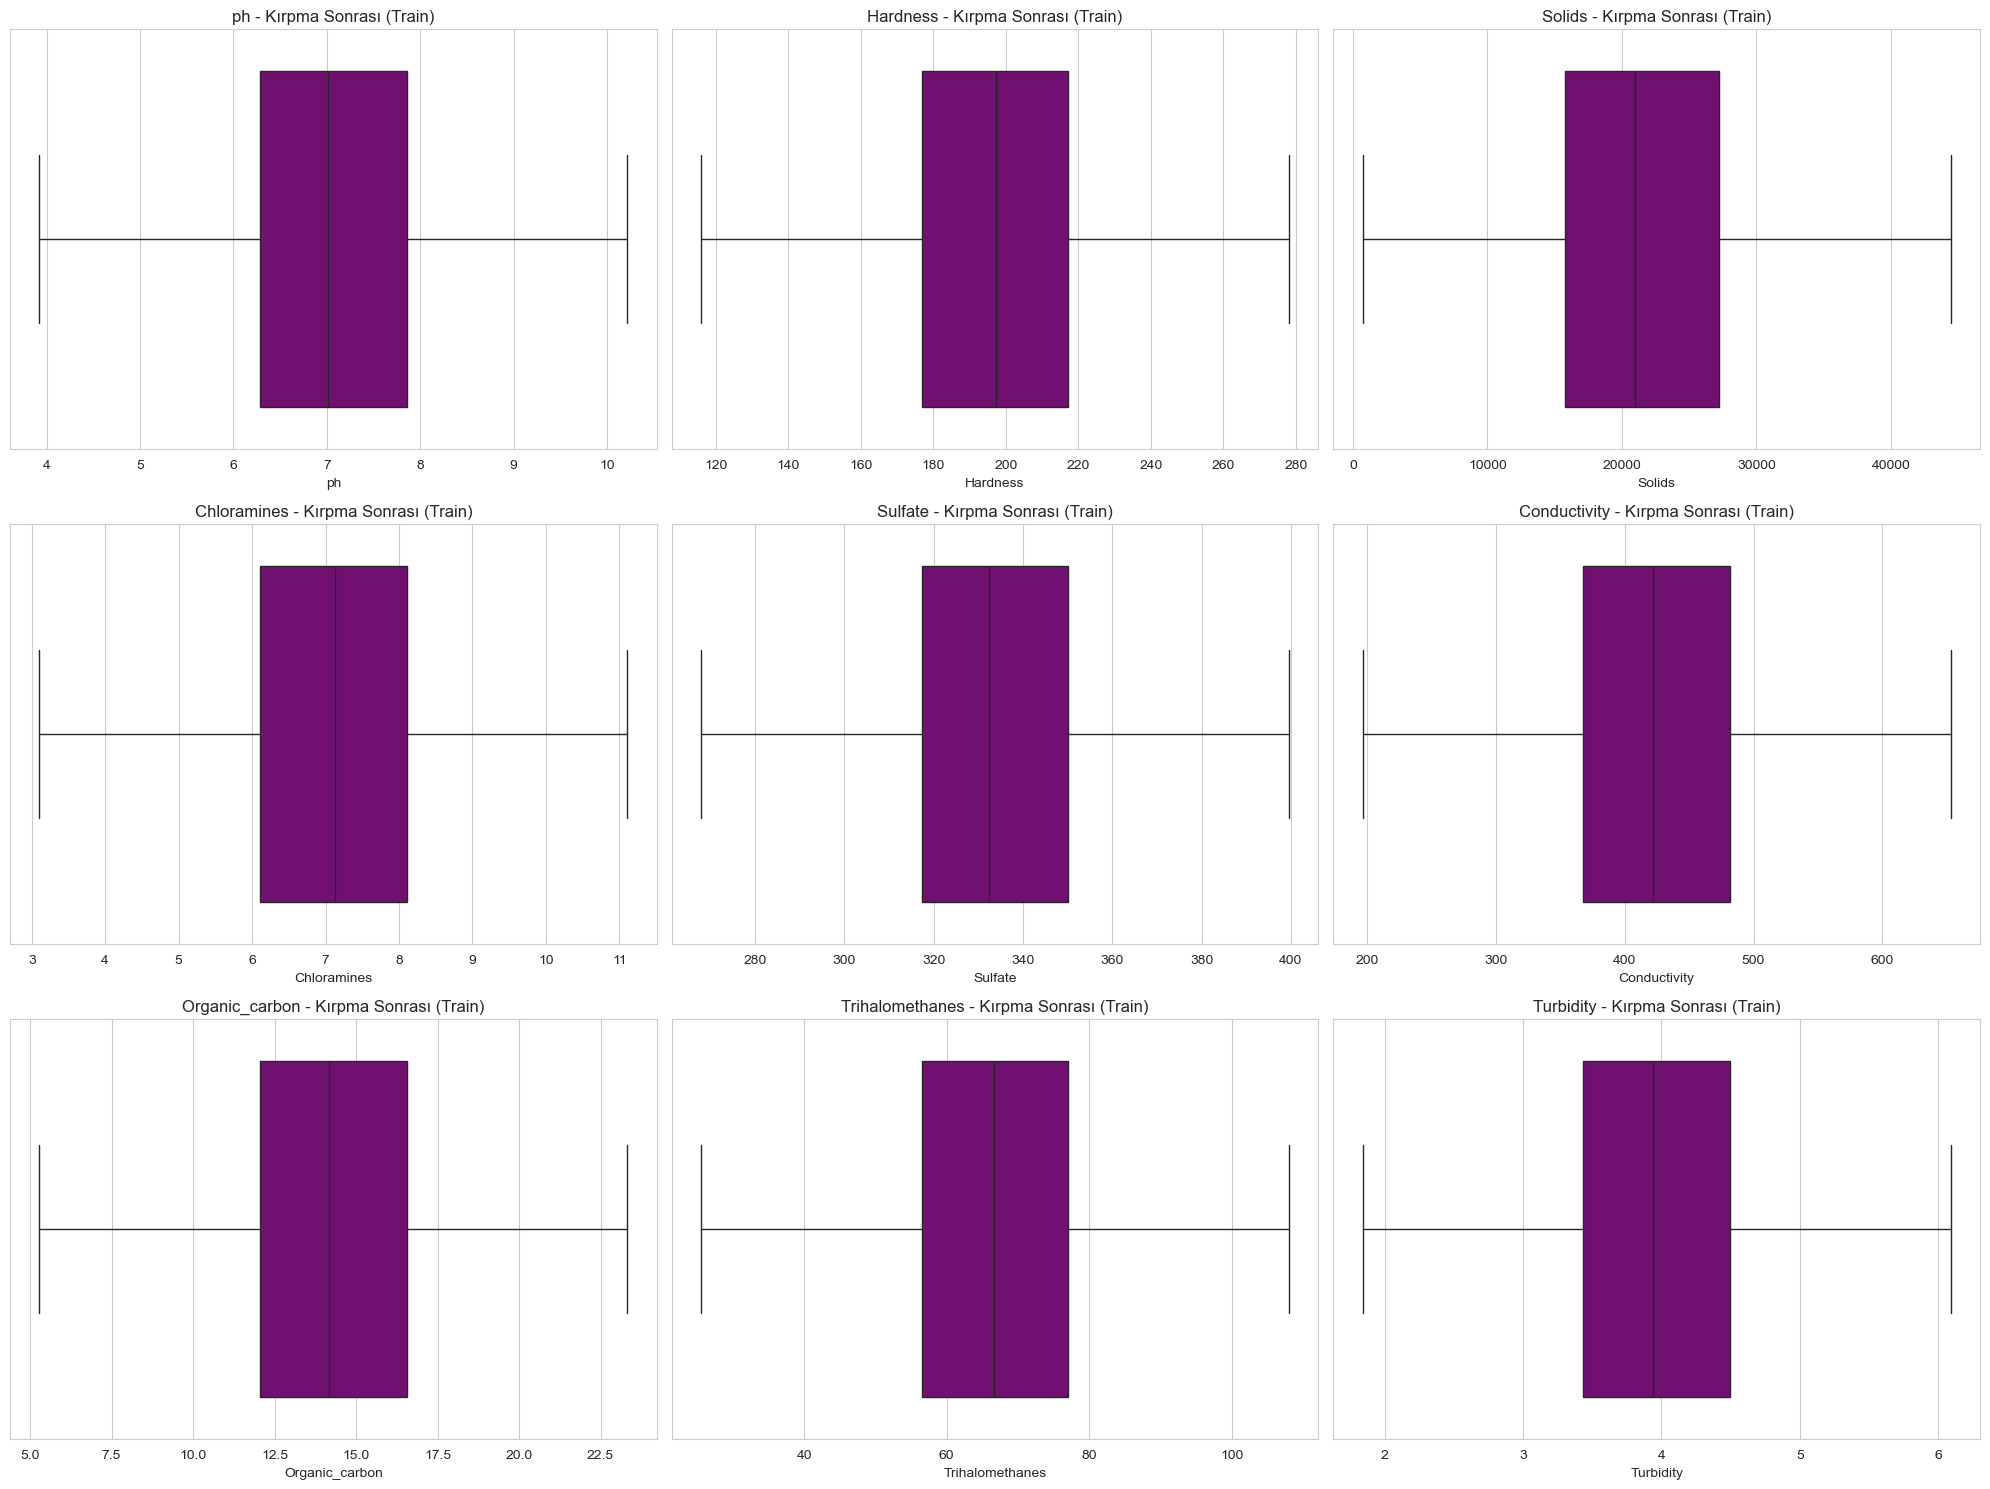

In [155]:
plt.figure(figsize=(20, 15))

for i, col in enumerate(X_train.columns):
    #3 satır, 3 sütun, 1'er 1'er arttırarak yerleştirir
    plt.subplot(3, 3, i + 1)
    
    sns.boxplot(x=X_train[col], color="purple")
    
    plt.title(f"{col} - Kırpma Sonrası (Train)")
    plt.xlabel(col)

plt.tight_layout() #başlıkların birbirine girmesini engeller
plt.show()

In [156]:
scaler = StandardScaler()

#fit: ortalamayı ve standart sapmayı sadece X_train üzerinden hesapla
scaler.fit(X_train)

#transform: hesaplanan değerleri kullanarak tüm setleri dönüştür
X_train_scaled_array = scaler.transform(X_train)
X_val_scaled_array = scaler.transform(X_val)
X_test_scaled_array = scaler.transform(X_test)

columns = X_train.columns

X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled_array, columns=columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=columns, index=X_test.index)

print("Ölçeklendirme (StandardScaler) başarıyla tamamlandı.")


Ölçeklendirme (StandardScaler) başarıyla tamamlandı.


In [157]:
#ilk 5 sütun için kontrol edelim
print("Eğitim Seti İstatistikleri (Ortalama 0, Std 1 olmalı):")
print(X_train_scaled.describe().T[['mean', 'std']].head())

print("\n--------------------------------------------------\n")

#test seti tam olarak 0 ve 1 olmaz (çünkü train'e göre ölçeklendi), ama yakın olmalı.
print("Test Seti İstatistikleri (0 ve 1'e yakın olmalı):")
print(X_test_scaled.describe().T[['mean', 'std']].head())

Eğitim Seti İstatistikleri (Ortalama 0, Std 1 olmalı):
                     mean       std
ph          -5.360833e-16  1.000218
Hardness     8.986367e-17  1.000218
Solids       6.817244e-17  1.000218
Chloramines -1.704311e-17  1.000218
Sulfate     -3.919915e-16  1.000218

--------------------------------------------------

Test Seti İstatistikleri (0 ve 1'e yakın olmalı):
                 mean       std
ph          -0.021607  1.020141
Hardness    -0.098789  0.988709
Solids      -0.061344  0.966177
Chloramines  0.042597  0.993635
Sulfate      0.032222  0.980162


Random Forest Doğruluk Oranı (Accuracy): 0.6808943089430894

Random Forest Detaylı Rapor:

              precision    recall  f1-score   support

           0       0.69      0.88      0.78       307
           1       0.64      0.35      0.45       185

    accuracy                           0.68       492
   macro avg       0.67      0.61      0.61       492
weighted avg       0.67      0.68      0.65       492



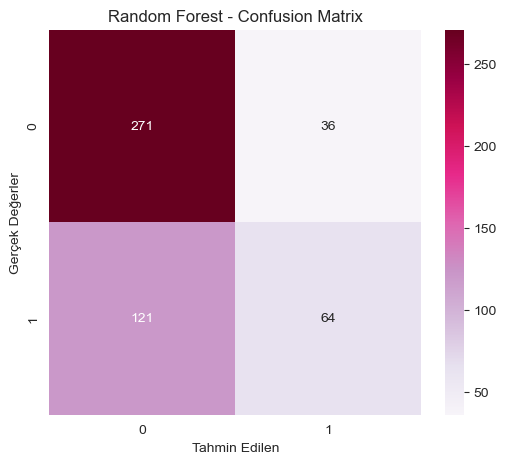

In [158]:

# n_estimators=100: 100 farklı karar ağacı kuracak
# random_state=42: Sonuçların her seferinde aynı çıkması için
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

#eğit
rf_model.fit(X_train_scaled, y_train)

#tahmin et
y_pred_rf = rf_model.predict(X_test_scaled)

#sonuçları değerlendir
print("Random Forest Doğruluk Oranı (Accuracy):", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Detaylı Rapor:\n")
print(classification_report(y_test, y_pred_rf))

#confusion matrix görselleştirmesi
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='PuRd')
#fmt='d':decimal integer(tam sayı)
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değerler')
plt.show()

C:\Users\helon\AppData\Local\Temp\ipykernel_4276\531745549.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='PuRd')


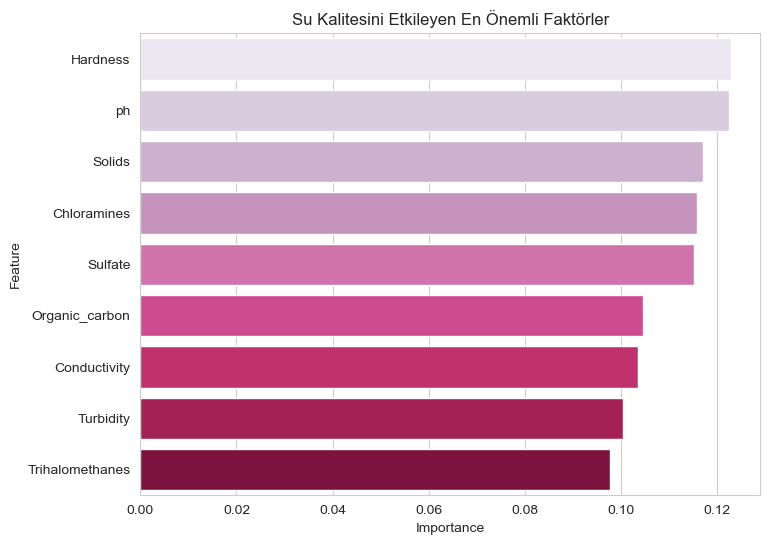

In [159]:
#hangi özellik (feature) daha önemli?
feature_importance = pd.DataFrame({
    'Feature': X.columns, #özellik isimi
    'Importance': rf_model.feature_importances_ #uzunluk, önem derecesi
}).sort_values(by='Importance', ascending=False) #büyükten küçüğe sıralar

plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='PuRd')
plt.title('Su Kalitesini Etkileyen En Önemli Faktörler')
plt.show()

Lojistik Regresyon Doğruluk Oranı (Accuracy): 0.6239837398373984

Detaylı Sınıflandırma Raporu:

              precision    recall  f1-score   support

           0       0.62      1.00      0.77       307
           1       0.00      0.00      0.00       185

    accuracy                           0.62       492
   macro avg       0.31      0.50      0.38       492
weighted avg       0.39      0.62      0.48       492



c:\Users\helon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\helon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\helon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


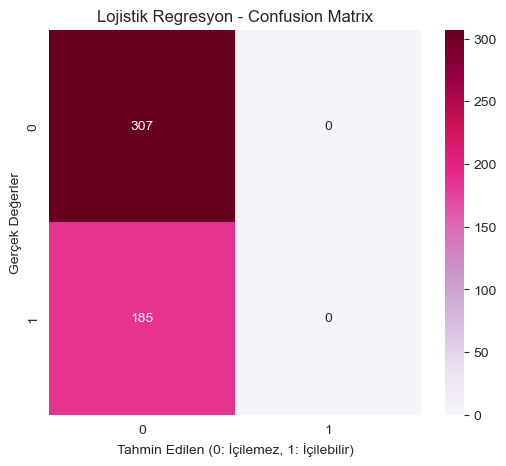

In [160]:
log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

#tahmin
y_pred_log = log_model.predict(X_test_scaled)

#sonuçların değerlendirilmesi ve görselleştirme
print("Lojistik Regresyon Doğruluk Oranı (Accuracy):", accuracy_score(y_test, y_pred_log))
print("\nDetaylı Sınıflandırma Raporu:\n")
print(classification_report(y_test, y_pred_log))

#confusion matrixm
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='PuRd')
plt.title('Lojistik Regresyon - Confusion Matrix')
plt.xlabel('Tahmin Edilen (0: İçilemez, 1: İçilebilir)')
plt.ylabel('Gerçek Değerler')
plt.show()

c:\Users\helon\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:37:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Doğruluk Oranı (Accuracy): 0.6524390243902439

Detaylı Rapor:
               precision    recall  f1-score   support

           0       0.68      0.82      0.75       307
           1       0.56      0.37      0.45       185

    accuracy                           0.65       492
   macro avg       0.62      0.60      0.60       492
weighted avg       0.64      0.65      0.63       492



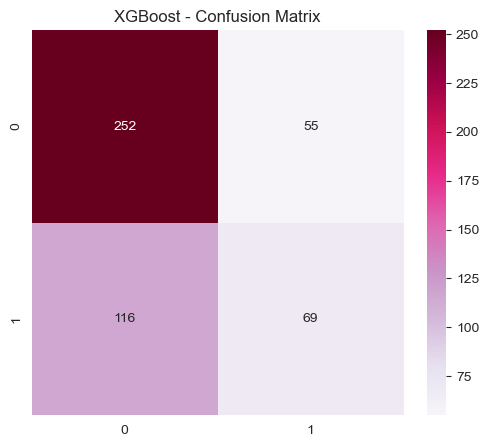

In [161]:
# use_label_encoder=False ve eval_metric='logloss' uyarıları susturmak için
xgb_model = XGBClassifier(
    n_estimators=100,      #ağaç sayısı
    learning_rate=0.1,     #öğrenme hızı (daha düşük değer = daha dikkatli öğrenme)
    max_depth=6,           #ağaç derinliği
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'

)

xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)

print("XGBoost Doğruluk Oranı (Accuracy):", accuracy_score(y_test, y_pred_xgb))
print("\nDetaylı Rapor:\n", classification_report(y_test, y_pred_xgb))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='PuRd') # Turuncu olsun
plt.title('XGBoost - Confusion Matrix')
plt.show()

KNN Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.69      0.78      0.73       307
           1       0.53      0.41      0.46       185

    accuracy                           0.64       492
   macro avg       0.61      0.59      0.60       492
weighted avg       0.63      0.64      0.63       492



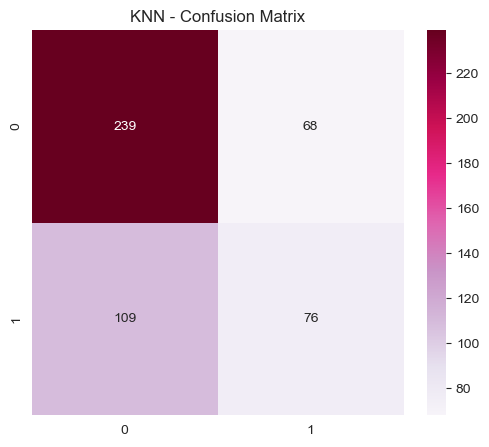

In [162]:
# n_neighbors=5: Tahmin yaparken en yakın 5 komşuya bak
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred_knn))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='PuRd')
plt.title('KNN - Confusion Matrix') 
plt.show()

c:\Users\helon\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model Performans Tablosu:
                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression     0.631      0.000   0.000     0.000
1                  KNN     0.611      0.465   0.365     0.409
2        Random Forest     0.664      0.577   0.331     0.421
3              XGBoost     0.654      0.540   0.409     0.465


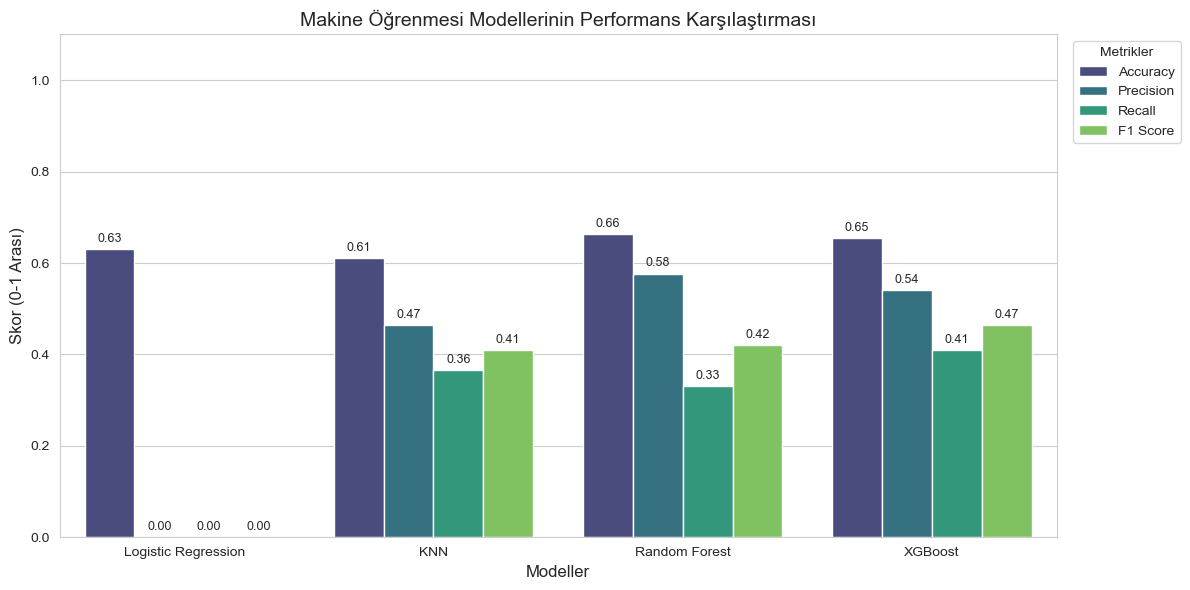

In [163]:
models = {
    "Logistic Regression": log_model,
    "KNN": knn_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

results = []

#döngü ile her model için tahmin yapıp metrikleri hesaplıyoruz
for name, clf in models.items():
    #test seti üzerinde tahmin
    y_pred = clf.predict(X_val_scaled)
    
    #metriklerin hesaplanması
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

#sonuçları dataframe'e çeviriyoruz
results_df = pd.DataFrame(results)

#değerleri daha okunaklı olması için 3 basamak yuvarlayalım
results_df = results_df.round(3)

print("Model Performans Tablosu:")
print(results_df)


df_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

grafik = sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", palette="viridis")

plt.title("Makine Öğrenmesi Modellerinin Performans Karşılaştırması", fontsize=14)
plt.ylabel("Skor (0-1 Arası)", fontsize=12)
plt.xlabel("Modeller", fontsize=12)
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title="Metrikler")

#değerleri çubukların üzerine yazdırma
for container in grafik.containers:
    grafik.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

c:\Users\helon\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:39:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Test Tablosu:
     Model  Accuracy  Precision  Recall  F1 Score
0  XGBoost     0.652      0.556   0.373     0.447


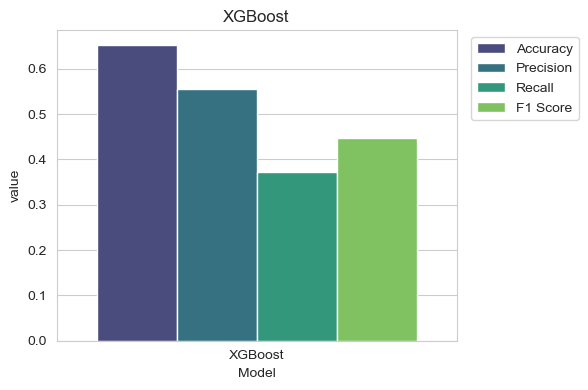

In [166]:

xgb_best = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_best.fit(X_train_scaled, y_train)

models = {"XGBoost": xgb_best}
results = []

y_pred = xgb_best.predict(X_test_scaled)
results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred)
})

df_results = pd.DataFrame(results).round(3)
print("Test Tablosu:")
print(df_results)

plt.figure(figsize=(6, 4))
sns.barplot(data=df_results.melt(id_vars="Model"), x="Model", y="value", hue="variable", palette="viridis")
plt.title("XGBoost")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()